In [1]:
# Import all the necessary libraries.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import Lasso
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split

In [2]:
# Sets the number of examples.
M = 100

# Reset pseudo random number generator so that the results are reproducible.
np.random.seed(42)

# Create target function and its noisy version.
x = np.random.uniform(-3, 3, (M, 1))
n = np.random.normal(0, 1, (M,1))
y = 2 + x + 0.5*x**2
y_noisy = y + n
            
# Mtest = 100
# x_test = np.linspace(-10, 10, Mtest).reshape(Mtest, 1)
# y_test = 2 + x_test + 0.5*x_test**2 + n

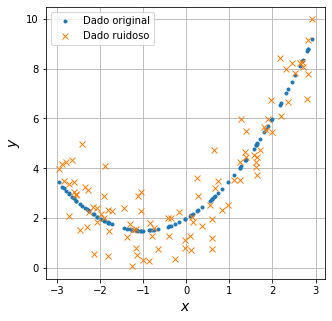

In [3]:
# Plot original data versus noisy version.
fig = plt.figure(figsize=(5,5))
plt.plot(x, y, '.', label='Dado original')
plt.plot(x, y_noisy, 'x', label='Dado ruidoso')
#plt.plot(x_test, y_test, 'o', label='Dado teste')
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
plt.savefig("target_function.png", dpi=600)
#Show the plot.
plt.show()

In [4]:
# Polynomial order.
model_order = 90

In [5]:
# Regularization factor.
lambdas = np.linspace(10**-10, 1, 1000)

2f) o valor ótimo para lambda é: 0.006006006105405405


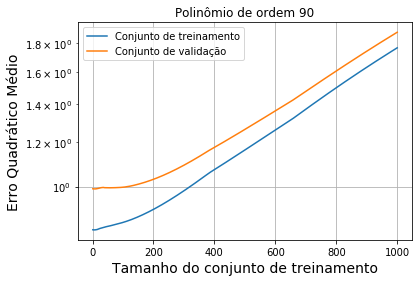

In [6]:
# exercício 2b-2c-2d-2f

# Split the whole set into random training and validation set.
x_train, x_val, y_train, y_val = train_test_split(x, y_noisy, test_size=0.3, random_state=10)

include_bias = False

N = 1000

a_hist = np.zeros((model_order, N)) if include_bias == False else np.zeros((model_order+1, N))

# vetor do erro de treinamento
error_training = []

# vetor do erro de validação/predição
error_validation = []

minimum_val_error = float("inf")

for i in range(0,len(lambdas)):
    # Instantiate a polynomial with the given degree.
    poly_features = PolynomialFeatures(degree=model_order, include_bias=include_bias)
    # Instantiate a scaler that will standardize the features.
    std_scaler = StandardScaler()
    # Instantiate a Lasso regressor.
    reg = Lasso(alpha=lambdas[i], tol=1, random_state=42) if lambdas[i] > 0 else LinearRegression()
    # Create a pipeline of actions.
    model = Pipeline([
        ("poly_features", poly_features),
        ("std_scaler", std_scaler),
        ("reg", reg),
    ])
    # Train model.
    model.fit(x_train, y_train)
    
    # Use the trained model for prediction of the training set.
    y_train_predict = model.predict(x_train)

    # Use the trained model for prediction of the validation set.
    y_val_predict = model.predict(x_val)       

    # Calculate MSE for training set.
    error_training.append(mean_squared_error(y_train, y_train_predict))
 
    # Calculate MSE for validation set.
    error_validation_aux = mean_squared_error(y_val, y_val_predict)
    error_validation.append(error_validation_aux)
    
    if error_validation_aux < minimum_val_error:
        l = lambdas[i]
        mdl = model
        a = mdl.named_steps['reg'].coef_
        a_hist[:,i] = a
        minimum_val_error = error_validation_aux
    
plt.plot(range(1,len(lambdas)+1), np.sqrt(error_training), label='Conjunto de treinamento')
plt.plot(range(1,len(lambdas)+1), np.sqrt(error_validation), label='Conjunto de validação')
plt.yscale('log')
plt.xlabel('Tamanho do conjunto de treinamento', fontsize=14)
plt.ylabel('Erro Quadrático Médio', fontsize=14)
plt.grid()
plt.title('Polinômio de ordem '+str(model_order))
plt.legend(loc='best')
print('2f) o valor ótimo para lambda é: '+str(l))

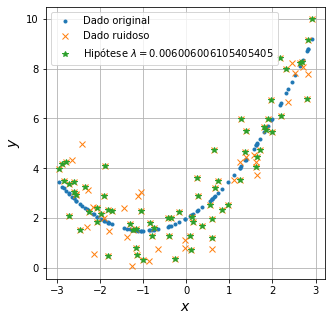

In [7]:
# exercício 2g
# Plote dos dados originais vs versão ruidosa vs modelo treinado.
fig = plt.figure(figsize=(5,5))
plt.plot(x, y, '.', label='Dado original')
plt.plot(x, y_noisy, 'x', label='Dado ruidoso')
plt.plot(x_train, y_train, '*', label='Hipótese $\lambda=$'+str(l))    
plt.xlabel('$x$', fontsize=14)
plt.ylabel('$y$', fontsize=14)
plt.legend()
plt.grid()
#Show the plot.
plt.show()

In [8]:
# exercício 2h
print('Valores dos pesos obtidos durante o treinamento do modelo com menor erro de validação:')
print(a)

Valores dos pesos obtidos durante o treinamento do modelo com menor erro de validação:
[ 1.53841974e+00  1.48143972e+00  1.49739040e-01 -1.76558778e-02
 -3.49748810e-02 -2.00484289e-02 -3.59624617e-02 -1.35042345e-02
 -2.29119476e-02 -2.16282893e-03 -1.27972285e-02 -0.00000000e+00
 -7.03612858e-03 -0.00000000e+00 -3.34198302e-03  6.32438432e-05
 -1.69260393e-03  9.45834281e-03 -0.00000000e+00  9.13386047e-03
 -0.00000000e+00  8.15015564e-03  0.00000000e+00  7.13881594e-03
  0.00000000e+00  6.15928640e-03  5.28178020e-03  7.50358009e-03
  7.17980724e-03  7.69003388e-03  7.42354631e-03  7.27645256e-03
  7.31272713e-03  6.77638590e-03  7.08486232e-03  6.28104224e-03
  6.79948567e-03  5.80818822e-03  6.48020210e-03  5.36101171e-03
  6.14059512e-03  4.93927697e-03  5.78993341e-03  4.54177120e-03
  5.43489197e-03  4.16695954e-03  5.08032347e-03  3.81320900e-03
  4.72972443e-03  3.47888401e-03  4.38556130e-03  3.16239321e-03
  4.04951256e-03  2.86221343e-03  3.72265308e-03  2.57690142e-03
  3

**2j) O que você percebe com relação aos pesos obtidos com as regressões Ridge e LASSO?**
- R: os valores dos pesos para a regressão Lasso tende a zero. Isso indica que há a ocorrência de um processo de seleção de variáveis, e leva a modelos de aproximação mais regulares, ou seja, menos complexos.